In [23]:
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/input/cnn-lstm-atten-2-10-fine-tuned-right/keras/default/1/fine_tuned_model_cnn_lstm_atten_2_10_early_right.keras", compile=False)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 200, 3)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 64)   │      1,408 │ inputs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ conv1d_6[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 200, 64)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 200, 64)   │     20,544 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ conv1d_7[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 200, 64)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 200, 64)   │     33,024 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ lstm_3[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 200, 64)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ dropout_20[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 200, 64)   │          0 │ dropout_20[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 200, 64)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_22[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 127,117 (496.55 KB)

 Trainable params: 127,117 (496.55 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import numpy as np
import pandas as pd

# Paths
pre_processed_data = "/kaggle/input/pre-processed/right_hand_acc/right_hand_acc"

# Load numpy files
x = np.load(f"{pre_processed_data}/X_windows_right_2s_10_full_ds.npy")
y_disease = np.load(f"{pre_processed_data}/Y_disease_right_2s_10_labels.npy")
y_activity = np.load(f"{pre_processed_data}/Y_activity_right_2s_10_labels.npy")
y_gender = np.load(f"{pre_processed_data}/gender.npy")
y_id = np.load(f"{pre_processed_data}/ids.npy")

print("Shapes:")
print("X:", x.shape)            # (num_samples, timesteps, features)
print("Disease:", y_disease.shape)
print("Activity:", y_activity.shape)
print("Gender:", y_gender.shape)
print("IDs:", y_id.shape)

Shapes:
X: (288144, 200, 3)
Disease: (288144,)
Activity: (288144,)
Gender: (288144,)
IDs: (288144,)


5075/5075 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
5075/5075 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
5075/5075 ━━━━━━

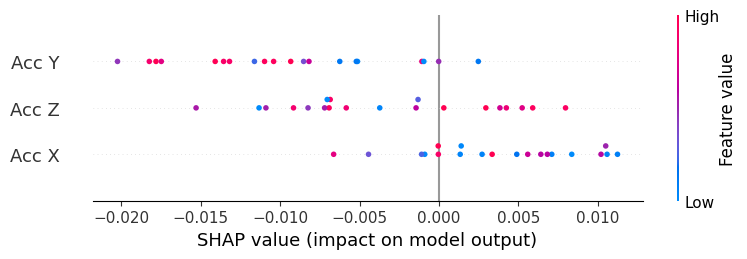

In [44]:
import shap

# 1. Wrapper Function for ACTIVITY
def model_predict_activity(data_flat):
    # Reshape back to 3D
    data_3d = data_flat.reshape(-1, 200, 3) 
    
    preds = model.predict(data_3d)
    
    if isinstance(preds, list):
        # --- CRITICAL CHANGE ---
        # Return index 1 for Activity
        return preds[1] 
    
    return preds

# 2. Prepare Data
x_flat = x.reshape(x.shape[0], -1)
background = x_flat[np.random.choice(x_flat.shape[0], 50, replace=False)]
test_samples = x_flat[0:20] # Small batch for speed

# 3. Initialize Explainer
explainer = shap.KernelExplainer(model_predict_activity, background)
shap_values = explainer.shap_values(test_samples)

# 4. Select Target Class to Explain
# shap_values is a list of arrays (one for each Activity Class: Sit, Stand, Walk, etc.)
# If you want to explain Class 2 ("Walking"):
target_class = 2
shap_val_target = shap_values[target_class]

# 5. Reshape and Plot
shap_val_3d = shap_val_target.reshape(-1, 200, 3)
test_samples_3d = test_samples.reshape(-1, 200, 3)

# Aggregate over time
shap_agg = np.sum(shap_val_3d, axis=1)
x_agg = np.mean(test_samples_3d, axis=1)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_agg, features=x_agg, feature_names=["Acc X", "Acc Y", "Acc Z"])

In [58]:
import tensorflow as tf
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection

# --- 1. INTEGRATED GRADIENTS (Generic) ---
def compute_ig(model, x_sample, head_idx, target_class_idx, steps=50):
    """
    Computes IG for a specific output head and class.
    head_idx: 0 for Disease, 1 for Activity
    """
    x = tf.cast(x_sample, tf.float32)
    baseline = tf.zeros_like(x)
    interpolated = [baseline + (i/steps)*(x - baseline) for i in range(steps+1)]
    
    grads = []
    for inp in interpolated:
        with tf.GradientTape() as tape:
            tape.watch(inp)
            preds = model(inp)
            
            # Select Head (Disease or Activity)
            if isinstance(preds, list):
                output = preds[head_idx]
            else:
                output = preds
                
            loss = output[:, target_class_idx]
            
        grads.append(tape.gradient(loss, inp).numpy())
        
    avg_grad = np.mean(np.stack(grads), axis=0)
    ig = (x.numpy() - baseline.numpy()) * avg_grad
    return ig[0] # Returns (200, 3)

# --- 2. OCCLUSION SENSITIVITY (Generic) ---
def compute_occlusion(model, x_sample, head_idx, target_class_idx, window=20, stride=5):
    """
    Computes Occlusion map for a specific output head.
    """
    timesteps = x_sample.shape[1]
    
    # Baseline
    preds = model.predict(x_sample, verbose=0)
    base_prob = preds[head_idx][0, target_class_idx] if isinstance(preds, list) else preds[0, target_class_idx]
    
    heatmap = np.zeros(timesteps)
    counts = np.zeros(timesteps)
    
    for t in range(0, timesteps - window + 1, stride):
        x_occ = x_sample.copy()
        x_occ[:, t:t+window, :] = 0.0
        
        preds_occ = model.predict(x_occ, verbose=0)
        prob_occ = preds_occ[head_idx][0, target_class_idx] if isinstance(preds, list) else preds_occ[0, target_class_idx]
        
        heatmap[t:t+window] += (base_prob - prob_occ)
        counts[t:t+window] += 1
        
    return heatmap / (counts + 1e-9)

# --- 3. ATTENTION MAP (Shared) ---
def compute_attention(model, x_sample, lstm_layer_name="lstm_3", att_layer_name="multi_head_attention_3"):
    """
    Extracts global attention profile (sum over heads and query axis).
    """
    lstm_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer(lstm_layer_name).output)
    lstm_out = lstm_model.predict(x_sample, verbose=0)
    
    att_layer = model.get_layer(att_layer_name)
    _, att_scores = att_layer(lstm_out, lstm_out, return_attention_scores=True)
    
    # Average heads (axis 1) -> (1, 200, 200) -> remove batch
    att_map = np.mean(att_scores, axis=1)[0]
    
    # Sum over Query axis to get "Global Importance" per timestep
    global_att = np.sum(att_map, axis=0)
    
    # Normalize
    return (global_att - global_att.min()) / (global_att.max() - global_att.min())

# --- 4. SHAP (Generic Wrapper) ---
def compute_shap_values(model, background, x_sample, head_idx, target_class_idx):
    """
    Computes SHAP values using KernelExplainer.
    Fixed to handle the nsamples > n_features requirement.
    """
    # Define wrapper dynamically based on head_idx
    def wrapper(data_flat):
        data_3d = data_flat.reshape(-1, 200, 3)
        preds = model.predict(data_3d, verbose=0)
        if isinstance(preds, list):
            return preds[head_idx]
        return preds

    # Flatten inputs
    x_flat = x_sample.reshape(1, -1)
    
    # Calculate number of features
    num_features = x_flat.shape[1]  # Should be 600
    
    # ---------------------------------------------------------
    # FIX: nsamples must be > num_features for LassoLarsIC
    # We set it to num_features + 50 to satisfy the solver.
    # ---------------------------------------------------------
    min_samples = num_features + 50
    
    bg_flat = background.reshape(background.shape[0], -1)
    
    explainer = shap.KernelExplainer(wrapper, bg_flat)
    
    print(f"Calculating SHAP with {min_samples} perturbations (Required for {num_features} features)...")
    
    # Use the calculated min_samples
    shap_vals = explainer.shap_values(x_flat, nsamples=min_samples, silent=True)
    
    # Select target class
    # Check if shap_vals is a list (multiclass) or array
    if isinstance(shap_vals, list):
        return shap_vals[target_class_idx].reshape(200, 3)
    else:
        # Binary classification might return single array
        if len(shap_vals.shape) == 3: # (1, 600, classes) - rare in kernel
             return shap_vals[0, :, target_class_idx].reshape(200, 3)
        return shap_vals.reshape(200, 3)

In [60]:
def plot_xai_dashboard(signal, ig_map, occ_map, att_map, shap_map, title="XAI Dashboard"):
    """
    Plots Signal, IG, Occlusion, Attention, and SHAP in a single view.
    """
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
    
    # Calculate Magnitude for context
    mag = np.sqrt(np.sum(signal**2, axis=1))
    
    # 1. Original Signal
    axes[0].plot(signal[:,0], label="Acc X", alpha=0.7)
    axes[0].plot(signal[:,1], label="Acc Y", alpha=0.7)
    axes[0].plot(signal[:,2], label="Acc Z", alpha=0.7)
    axes[0].set_title(f"{title}: Raw Signals")
    axes[0].legend(loc="upper right")
    
    # 2. Integrated Gradients (Heatmap on Signal)
    # Sum absolute IG across features for a 1D importance line
    ig_sum = np.sum(np.abs(ig_map), axis=1)
    ig_norm = (ig_sum - ig_sum.min()) / (ig_sum.max() - ig_sum.min())
    
    axes[1].plot(mag, 'k', alpha=0.3, label="Magnitude")
    axes[1].fill_between(range(200), 0, ig_norm, color='orange', alpha=0.7, label="IG Importance")
    axes[1].set_title("Integrated Gradients (Sum of Features)")
    axes[1].legend()

    # 3. Occlusion Sensitivity
    axes[2].plot(mag, 'k', alpha=0.3, label="Magnitude")
    axes[2].fill_between(range(200), 0, occ_map, color='red', alpha=0.6, label="Occlusion Drop")
    axes[2].set_title("Occlusion Sensitivity (Prob Drop)")
    axes[2].legend()

    # 4. Attention Map
    axes[3].plot(mag, 'k', alpha=0.3, label="Magnitude")
    axes[3].fill_between(range(200), 0, att_map, color='purple', alpha=0.6, label="Global Attention")
    axes[3].set_title("Self-Attention (Global Weights)")
    axes[3].legend()

    # 5. SHAP Values
    # Sum SHAP across features for 1D view
    shap_sum = np.sum(shap_map, axis=1)
    axes[4].plot(mag, 'k', alpha=0.3, label="Magnitude")
    # Color positive/negative SHAP differently
    axes[4].fill_between(range(200), 0, shap_sum, where=(shap_sum>0), color='green', alpha=0.6, label="Positive Contribution")
    axes[4].fill_between(range(200), 0, shap_sum, where=(shap_sum<0), color='blue', alpha=0.6, label="Negative Contribution")
    axes[4].set_title("SHAP Values (Sum of Features)")
    axes[4].legend()

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

Running XAI for DISEASE on Sample ID 1844...
Calculating SHAP with 650 perturbations (Required for 600 features)...


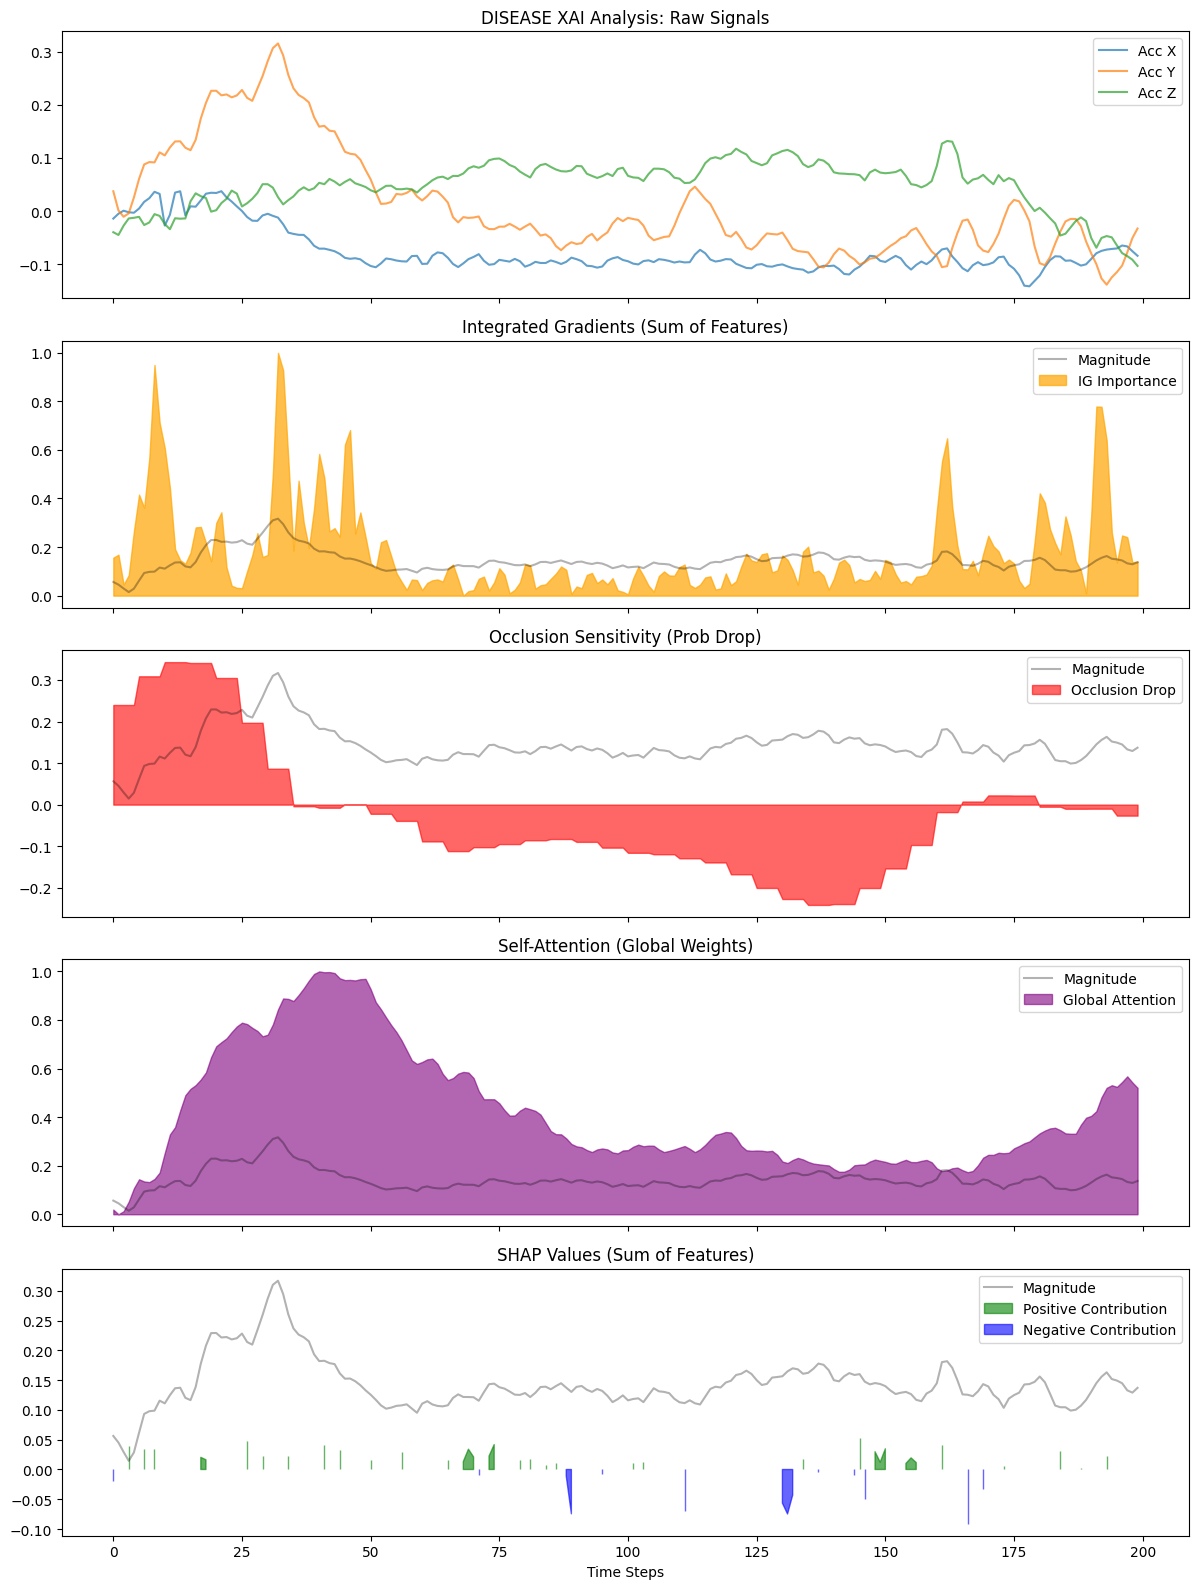

In [61]:
# --- SETTINGS FOR DISEASE ---
HEAD_DISEASE = 0
CLASS_POSITIVE = 1  # Assuming 1 = Disease Positive

# 1. Select a POSITIVE Disease Sample
pos_idx = np.where(y_disease == CLASS_POSITIVE)[0][0] # First positive sample
sample_d = x[pos_idx:pos_idx+1] # Shape (1, 200, 3)
print(f"Running XAI for DISEASE on Sample ID {pos_idx}...")

# 2. Compute Metrics
ig_d = compute_ig(model, sample_d, HEAD_DISEASE, CLASS_POSITIVE)
occ_d = compute_occlusion(model, sample_d, HEAD_DISEASE, CLASS_POSITIVE)
att_d = compute_attention(model, sample_d) # Layer names must match your model!

# Prepare background for SHAP (Flattened)
x_flat = x.reshape(x.shape[0], -1)
background = x_flat[np.random.choice(x_flat.shape[0], 50, replace=False)]
shap_d = compute_shap_values(model, background, sample_d, HEAD_DISEASE, CLASS_POSITIVE)

# 3. Plot Dashboard
plot_xai_dashboard(sample_d[0], ig_d, occ_d, att_d, shap_d, title="DISEASE XAI Analysis")

Running XAI for ACTIVITY (Class 2) on Sample ID 103...
Calculating SHAP with 650 perturbations (Required for 600 features)...


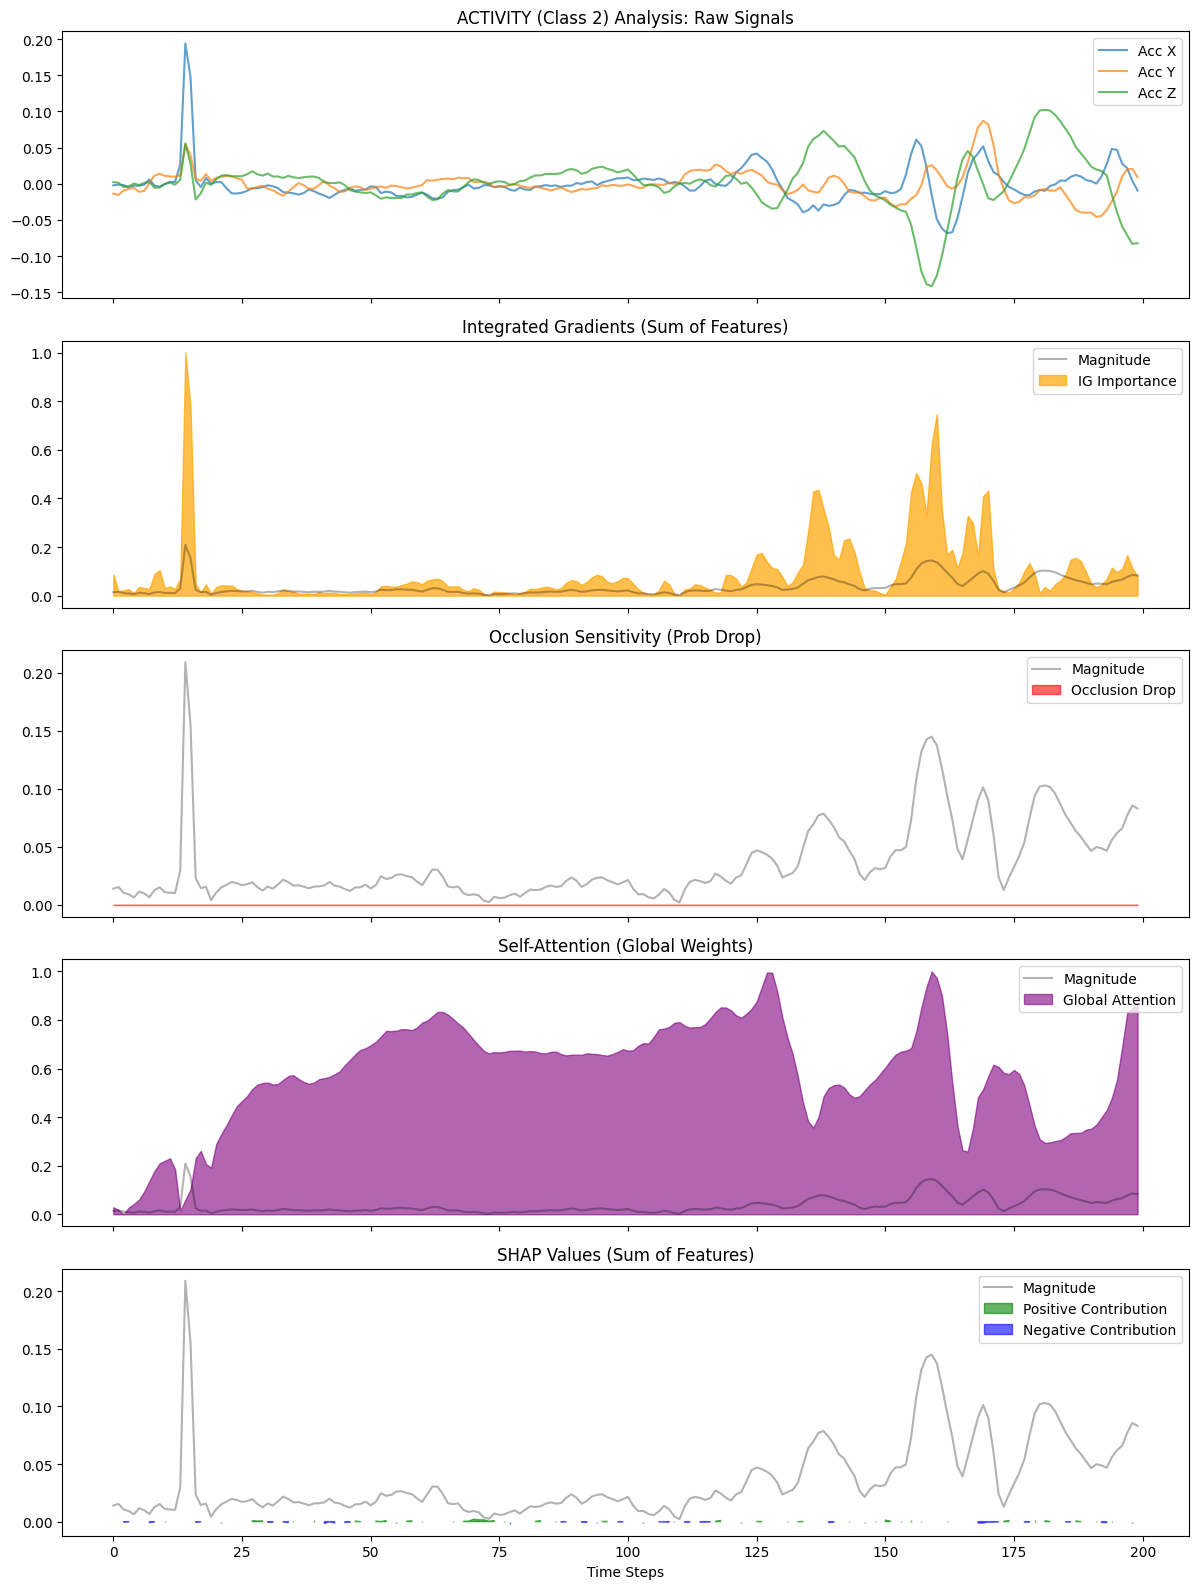

In [62]:
# --- SETTINGS FOR ACTIVITY ---
HEAD_ACTIVITY = 1
CLASS_WALKING = 2 # Change this to the activity ID you want to explain (e.g., Walking)

# 1. Select a Sample for this Activity
act_idx = np.where(y_activity == CLASS_WALKING)[0][0] # First walking sample
sample_a = x[act_idx:act_idx+1]
print(f"Running XAI for ACTIVITY (Class {CLASS_WALKING}) on Sample ID {act_idx}...")

# 2. Compute Metrics
ig_a = compute_ig(model, sample_a, HEAD_ACTIVITY, CLASS_WALKING)
occ_a = compute_occlusion(model, sample_a, HEAD_ACTIVITY, CLASS_WALKING)
att_a = compute_attention(model, sample_a) # Attention is shared, but input context changes

shap_a = compute_shap_values(model, background, sample_a, HEAD_ACTIVITY, CLASS_WALKING)

# 3. Plot Dashboard
plot_xai_dashboard(sample_a[0], ig_a, occ_a, att_a, shap_a, title=f"ACTIVITY (Class {CLASS_WALKING}) Analysis")

In [63]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

def calculate_consistency(map1, map2, top_percentile=90):
    """
    Calculates Cohen's Kappa between two importance maps.
    args:
        map1, map2: 1D arrays of importance scores (length 200).
        top_percentile: Threshold to select 'important' features (e.g., 90th percentile).
    """
    # 1. Normalize both maps to 0-1 range
    map1_norm = (map1 - map1.min()) / (map1.max() - map1.min())
    map2_norm = (map2 - map2.min()) / (map2.max() - map2.min())
    
    # 2. Threshold to create Binary Masks (Important vs Not Important)
    # We select the top 10% most important features
    thresh1 = np.percentile(map1_norm, top_percentile)
    thresh2 = np.percentile(map2_norm, top_percentile)
    
    mask1 = (map1_norm >= thresh1).astype(int)
    mask2 = (map2_norm >= thresh2).astype(int)
    
    # 3. Calculate Kappa
    kappa = cohen_kappa_score(mask1, mask2)
    return kappa

# --- Example Usage with your previous results ---
# sum absolute values across channels to get 1D importance
ig_1d = np.sum(np.abs(ig_d), axis=1)    # Integrated Gradients
shap_1d = np.sum(np.abs(shap_d), axis=1) # SHAP

k_score = calculate_consistency(ig_1d, shap_1d)

print(f"Consistency (Cohen's Kappa) between IG and SHAP: {k_score:.4f}")

if k_score > 0.6:
    print("Strong Agreement: Both methods highlight similar features.")
elif k_score > 0.4:
    print("Moderate Agreement.")
else:
    print("Weak Agreement: The methods are finding different explanations!")

Consistency (Cohen's Kappa) between IG and SHAP: 0.0556
Weak Agreement: The methods are finding different explanations!


I0000 00:00:1764767880.321929     109 service.cc:148] XLA service 0x7f3f5cea3e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764767880.323864     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764767880.323891     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764767880.772247     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


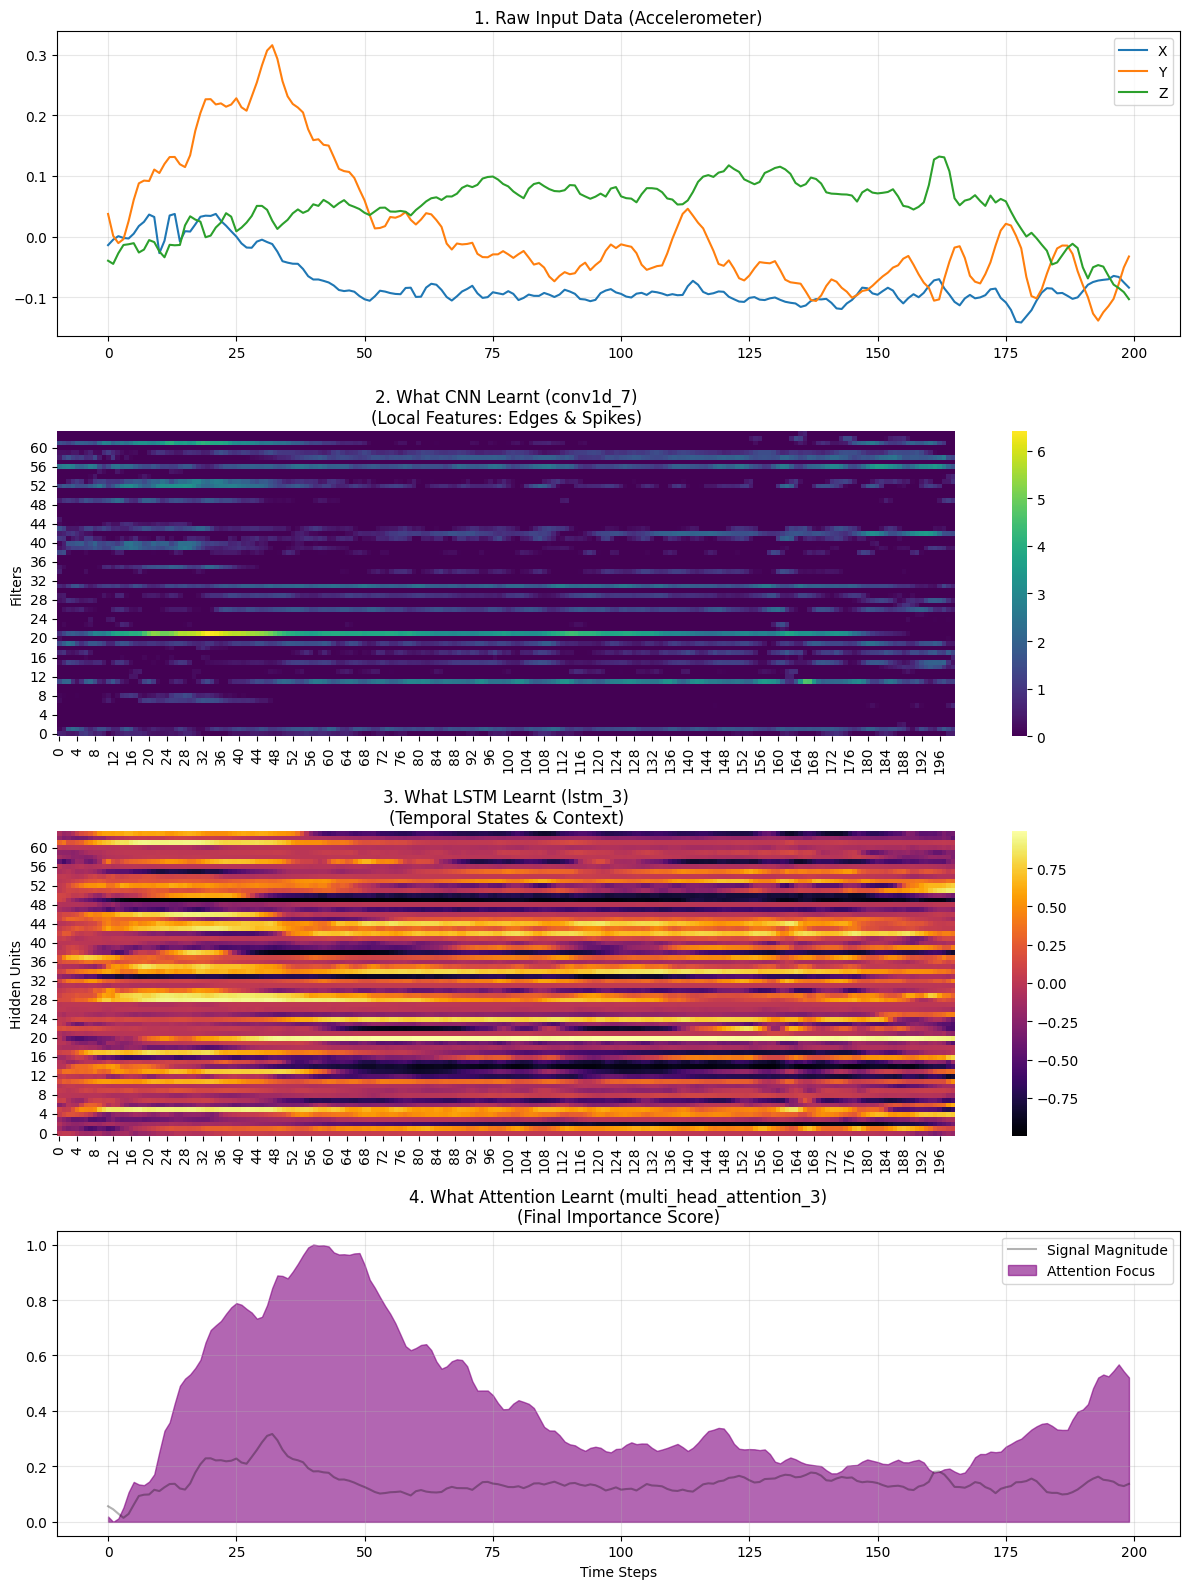

In [66]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_internal_learning(model, sample, cnn_layer_name, lstm_layer_name, att_layer_name):
    """
    Visualizes the outputs of CNN, LSTM, and the Attention Weights.
    """
    # --- 1. SETUP INTERMEDIATE MODELS ---
    # CNN Output
    cnn_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer(cnn_layer_name).output)
    
    # LSTM Output
    lstm_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer(lstm_layer_name).output)
    
    # Attention Layer 
    att_layer = model.get_layer(att_layer_name)
    
    # --- 2. GET ACTIVATIONS ---
    # CNN & LSTM features
    cnn_out = cnn_model.predict(sample, verbose=0) 
    lstm_out = lstm_model.predict(sample, verbose=0) 
    
    # Attention Scores
    # We pass LSTM output into Attention because that's how the model is built
    _, att_scores = att_layer(lstm_out, lstm_out, return_attention_scores=True)
    att_map = np.mean(att_scores, axis=1)[0] # Average over heads

    # --- 3. PLOT EVERYTHING ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    
    # Plot A: Original Input
    mag = np.sqrt(np.sum(sample[0]**2, axis=1))
    axes[0].plot(sample[0])
    axes[0].set_title("1. Raw Input Data (Accelerometer)")
    axes[0].legend(['X', 'Y', 'Z'])
    axes[0].grid(True, alpha=0.3)
    
    # Plot B: CNN Learning
    sns.heatmap(cnn_out[0].T, cmap='viridis', ax=axes[1], cbar=True)
    axes[1].set_title(f"2. What CNN Learnt ({cnn_layer_name})\n(Local Features: Edges & Spikes)")
    axes[1].set_ylabel("Filters")
    axes[1].invert_yaxis()
    
    # Plot C: LSTM Learning
    sns.heatmap(lstm_out[0].T, cmap='inferno', ax=axes[2], cbar=True)
    axes[2].set_title(f"3. What LSTM Learnt ({lstm_layer_name})\n(Temporal States & Context)")
    axes[2].set_ylabel("Hidden Units")
    axes[2].invert_yaxis()
    
    # Plot D: Attention Learning
    global_att = np.sum(att_map, axis=0)
    att_norm = (global_att - global_att.min()) / (global_att.max() - global_att.min())
    
    axes[3].plot(mag, 'k', alpha=0.3, label="Signal Magnitude")
    axes[3].fill_between(range(len(att_norm)), 0, att_norm, color='purple', alpha=0.6, label="Attention Focus")
    axes[3].set_title(f"4. What Attention Learnt ({att_layer_name})\n(Final Importance Score)")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# --- RUN WITH CORRECT NAMES ---

# 1. Select a Sample (Disease Positive)
pos_idx = np.where(y_disease == 1)[0][0]
sample = x[pos_idx:pos_idx+1]

# 2. UPDATED LAYER NAMES
cnn_name = "conv1d_7"            # Changed from conv1d_4 to conv1d_7
lstm_name = "lstm_3"             # Correct
att_name = "multi_head_attention_3" # Correct

visualize_internal_learning(model, sample, cnn_name, lstm_name, att_name)